### Name : ADITYA SONI
### PID : 246052 
### Date : 09/02/26
### Exp No : 04
### Title : Classification Using Logistic Regression, Decision Tree, and k-Nearest Neighbors

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score , confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

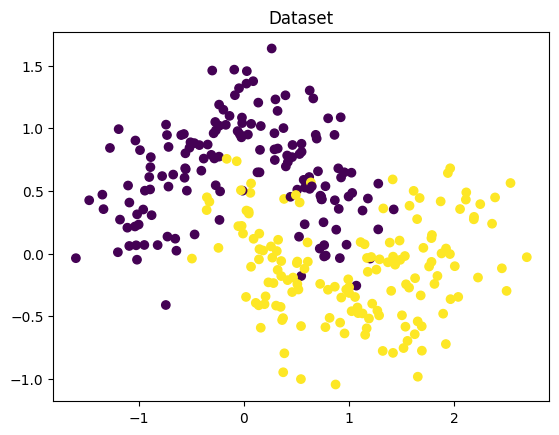

In [2]:
# step 1 - create dataset
x,y = make_moons(n_samples = 300 , noise = 0.25 , random_state = 42)

plt.scatter(x[:,0],x[:,1],c=y)
plt.title("Dataset")
plt.show()


In [3]:
# step 2 - train test split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=0)


In [4]:
#step 3 - scaling (important for LR and KNN)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [5]:
lr = LogisticRegression()
lr.fit(x_train_scaled,y_train)
y_pred_lr = lr.predict(x_test_scaled)
print("Logistic Regression")
print("Accuracy : ",accuracy_score(y_test,y_pred_lr))
print("Confusion Matrix :\n " , confusion_matrix(y_test,y_pred_lr))

Logistic Regression
Accuracy :  0.8777777777777778
Confusion Matrix :
  [[34  5]
 [ 6 45]]


In [6]:
dt = DecisionTreeClassifier(max_depth = 101)
dt.fit(x_train,y_train)
y_pred_dt = dt.predict(x_test)
print ("Decision Tree")
print("Accuracy : ",accuracy_score(y_test,y_pred_dt))
print("Confusion Matrix :\n " , confusion_matrix(y_test,y_pred_dt))

Decision Tree
Accuracy :  0.8888888888888888
Confusion Matrix :
  [[37  2]
 [ 8 43]]


In [7]:
knn = KNeighborsClassifier(n_neighbors=101)
knn.fit(x_train_scaled,y_train)
y_pred_knn = knn.predict(x_test_scaled)
print ("knn")
print("Accuracy : ",accuracy_score(y_test,y_pred_knn))
print("Confusion Matrix :\n " , confusion_matrix(y_test,y_pred_knn))

knn
Accuracy :  0.8555555555555555
Confusion Matrix :
  [[33  6]
 [ 7 44]]


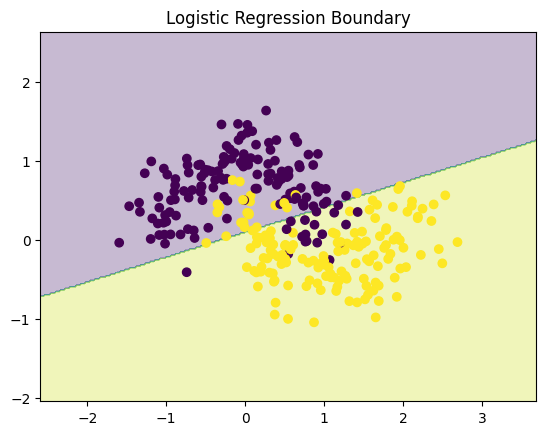

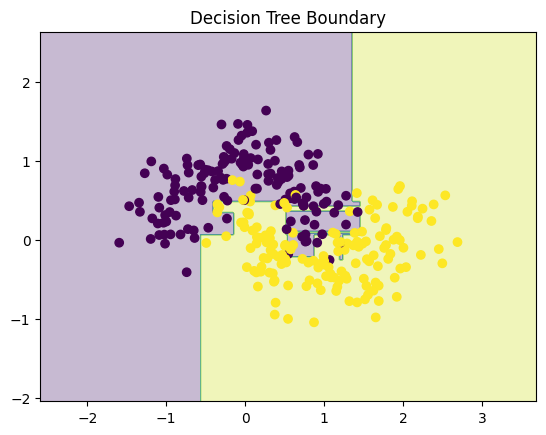

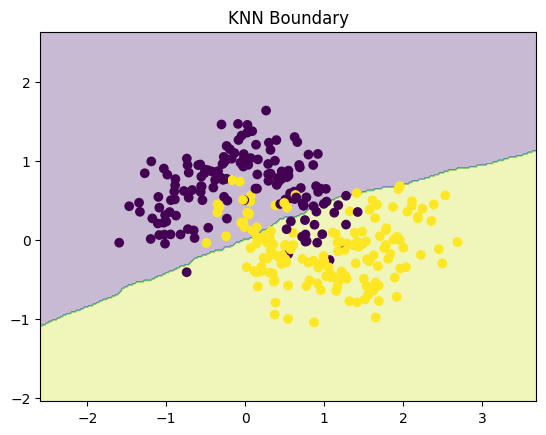

In [8]:
def plot_boundary(model, scaled, title):
    h = 0.02

    x_min, x_max = x[:, 0].min() - 1, x[:, 0].max() + 1
    y_min, y_max = x[:, 1].min() - 1, x[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    if scaled:
        grid = scaler.transform(grid)

    z = model.predict(grid)
    z = z.reshape(xx.shape)

    plt.contourf(xx, yy, z, alpha=0.3)
    plt.scatter(x[:, 0], x[:, 1], c=y)
    plt.title(title)
    plt.show()
plot_boundary(lr, True, "Logistic Regression Boundary")
plot_boundary(dt, False, "Decision Tree Boundary")
plot_boundary(knn, True, "KNN Boundary")
